# [5.0] DESI DR1 x LSST DP2 Data

In this notebook, we will:
- **move the catalog** at NERSC to provide a public endpoint of our DESI DR1 catalog
- **crossmatch** the NERSC-hosted DESI DR1 catalog with the LSST DP2 Data at USDF 
  - specifically, the DP2 v30_0_6 dia_object_collection (accessed May 28)
- **save** the resulting catalog on USDF
- discuss **performance and resource use** of the crossmatch

## Pre-set up: move catalog to public NERSC dir

First, I moved the catalog we've been using through the last four sections:
```bash
mv /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark \
   /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark
```

And I set the permissions on noth my public dir and the catalog inside it:
```bash
chmod o+rX /global/cfs/cdirs/cosmo/www/users/olynn
chmod o+rX -R /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark
```

## Set up

In [1]:
import time
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog

In [2]:
# Make a dask client

client = Client(
    n_workers=32,
    memory_limit="auto"
)

## Load catalogs

### Load DESI

In [3]:
desi_cat = lsdb.open_catalog("https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

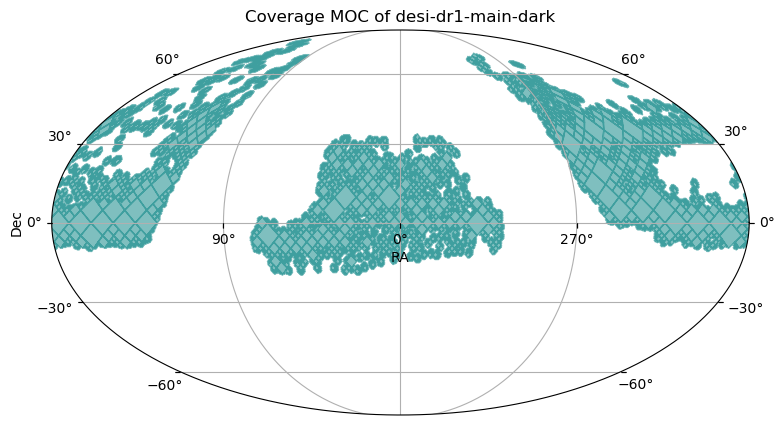

In [4]:
desi_cat.plot_coverage()

### Load DP2

In [5]:
dp2_cat = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/dia_object_collection")
dp2_cat

,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource
npartitions=33850,,,,,,,
"Order: 4, Pixel: 1059",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
"Order: 5, Pixel: 4249",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...
"Order: 11, Pixel: 50315377",...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

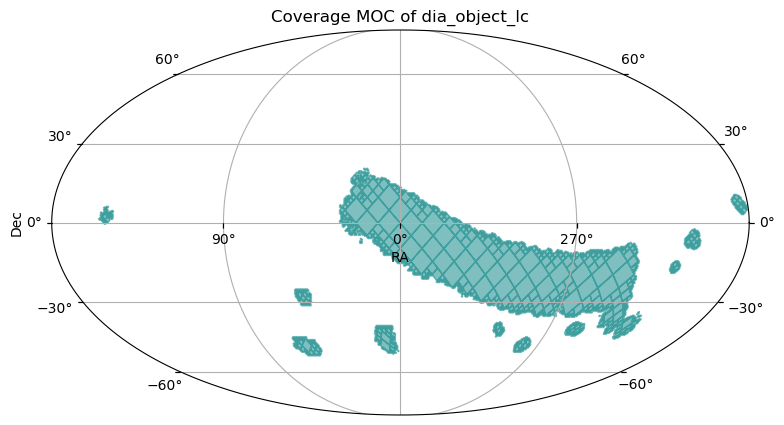

In [6]:
dp2_cat.plot_coverage()

## Do crossmatch

In [7]:
desi_x_dp2 = desi_cat.crossmatch(dp2_cat, suffix_method="overlapping_columns", suffixes=("_desi", "_lsst_dp2"))

In [8]:
start = time.perf_counter()

catalog_name = "desi_x_lsst_dp2"
target_user_dir = Path("/sdf/home/o/olynn/catalogs/")
with performance_report(filename="crossmatch_report.html"):
    desi_x_dp2.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name,
    )

elapsed = time.perf_counter() - start

/sdf/home/o/olynn/.local/lib/python3.13/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
/sdf/home/o/olynn/.local/lib/python3.13/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])


In [9]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

Crossmatch took 4m 58.8s


## Verify crossmatched catalog

In [10]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /sdf/home/o/olynn/catalogs/desi_x_lsst_dp2 ... 
Found 2125 partitions.
Approximate coverage is 3.85 % of the sky.


True

In [11]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

7.3G	/sdf/home/o/olynn/catalogs/desi_x_lsst_dp2


/sdf/group/rubin/sw/conda/envs/lsst-scipipe-13.0.0/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=2503736) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [12]:
desi_x_dp2_cat = lsdb.open_catalog(output_catalog)
desi_x_dp2_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,_dist_arcsec
npartitions=2125,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 17107",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",double[pyarrow]
"Order: 6, Pixel: 17109",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49124",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12282",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_lsst_dp2'}>)

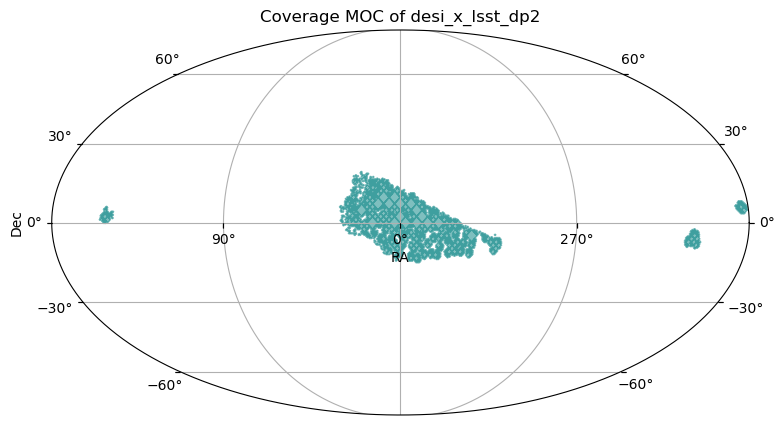

In [13]:
# Plot coverage

desi_x_dp2_cat.plot_coverage()

In [14]:
# See the first few rows

df = desi_x_dp2_cat.head(5)
df

TARGETID   TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                                
1203863513569649040  39627437792825537  351.428181  -14.683122  1.368533   
1203863976572888979  39627437792823928  351.350538   -14.67635  0.146449   
1204005882254261797  39627455413094458  353.658806  -14.040638  3.617634   
1204008106340562315  39627455413092836  353.583011   -13.94792  1.228033   
1204008148320016189  39627455413094471  353.659641  -14.004045   3.09752   

                         ZERR  \
_healpix_29                     
1203863513569649040  0.000138   
1203863976572888979  0.000004   
1204005882254261797   0.00031   
1204008106340562315  0.000786   
1204008148320016189  0.000161   

                                                             spectra_b  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 3600.0, flux: 5.040675, ivar: 0....   
1203863976572888979  [{wavelength: 3600.0, flux: 64.870834, ivar: 0...   
1204005882254261797  [{wavelength: 3600.0, flux: -0.637333, ivar: 0...   
1204008106340562315  [{wavelength: 3600.0, flux: 3.158296, ivar: 0....   
1204008148320016189  [{wavelength: 3600.0, flux: -2.019307, ivar: 0...   

                                                             spectra_r  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 5760.0, flux: 4.024427, ivar: 0....   
1203863976572888979  [{wavelength: 5760.0, flux: 36.507702, ivar: 0...   
1204005882254261797  [{wavelength: 5760.0, flux: 3.039543, ivar: 0....   
1204008106340562315  [{wavelength: 5760.0, flux: 3.824352, ivar: 0....   
1204008148320016189  [{wavelength: 5760.0, flux: 4.587873, ivar: 0....   

                                                             spectra_z  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 7520.0, flux: 0.567026, ivar: 2....   
1203863976572888979  [{wavelength: 7520.0, flux: 187.865128, ivar: ...   
1204005882254261797  [{wavelength: 7520.0, flux: 1.360092, ivar: 6....   
1204008106340562315  [{wavelength: 7520.0, flux: 0.007672, ivar: 8....   
1204008148320016189  [{wavelength: 7520.0, flux: 0.922159, ivar: 7....   

                           dec         diaObjectId  nDiaSources          ra  \
_healpix_29                                                                   
1203863513569649040 -14.683135  770721298467782915            1  351.428182   
1203863976572888979  -14.67635  770721367187259405           28  351.350518   
1204005882254261797 -14.040633  770738134739583189            4  353.658795   
1204008106340562315 -13.947923  770738821934350543            4  353.583073   
1204008148320016189 -14.004058  770738134739583163            2  353.659605   

                     tract                              diaObjectForcedSource  \
_healpix_29                                                                     
1203863513569649040   7297  [{band: 'i', coord_dec: -14.683135, coord_ra: ...   
1203863976572888979   7297  [{band: 'i', coord_dec: -14.67635, coord_ra: 3...   
1204005882254261797   7299  [{band: 'r', coord_dec: -14.040633, coord_ra: ...   
1204008106340562315   7299  [{band: 'r', coord_dec: -13.947923, coord_ra: ...   
1204008148320016189   7299  [{band: 'r', coord_dec: -14.004058, coord_ra: ...   

                                                             diaSource  \
_healpix_29                                                              
1203863513569649040  [{band: 'g', centroid_flag: False, dec: -14.68...   
1203863976572888979  [{band: 'i', centroid_flag: False, dec: -14.67...   
1204005882254261797  [{band: 'g', centroid_flag: False, dec: -14.04...   
1204008106340562315  [{band: 'g', centroid_flag: False, dec: -13.94...   
1204008148320016189  [{band: 'r', centroid_flag: False, dec: -14.00...   

                     _dist_arcsec  
_healpix_29                    

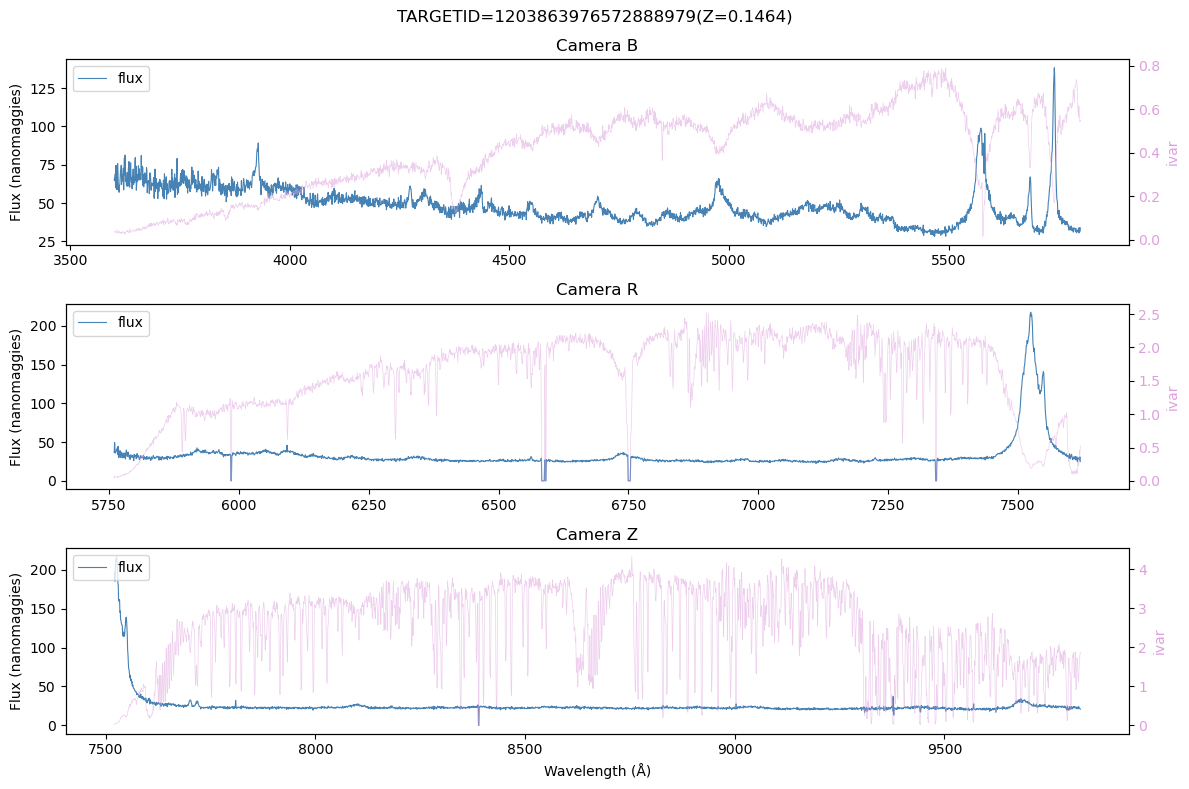

In [15]:
# Plot spectra of a row

target_idx = 1  # Picking 1 for the example, as it has the lowest redshift and a nice spectrum :)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"TARGETID={df.index[target_idx]}(Z={df['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Performance analysis

In [1]:
# Generate markdown tables for the Dask dashboard reports

from dask_report_utils import client_table, metrics_table

print(client_table("crossmatch_report.html", memory_limit_per_worker="auto"), "\n")
print(metrics_table("crossmatch_report.html"), "\n")

| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | N/A |
| Total threads | 128 |
| Memory per worker | auto |
| Total memory | 546.02 GiB | 

| Metric | Value |
|---|---|
| Total tasks | 15750 |
| Wall time | 297 |
| Compute time (all workers) | 5hr 11m |
| Transfer time | 4hr 26m |
| Disk read time | N/A |
| Disk write time | 14.74 s |
| Total bandwidth | N/A | 



### 1. Setup
The crossmatch was run on a USDF (S3DF) node using a local Dask distributed client. 

The full DESI DR1 Main Survey (Dark Program), accessed remotely over HTTPS from the NERSC portal (`https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/`), was crossmatched against the LSST DP2 catalog (as of May 28, 2025), read locally from the USDF filesystem (`/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/dia_object_collection`).

The Dask client was configured as follows:

| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 128 |
| Memory per worker | 14 GB |
| Total memory | 546.02 GiB |

### 2. Wall Time
The full crossmatch — from the `desi.crossmatch(dp2).compute()` call to completion —
took **297 seconds** (~4m 57s) as measured by `time.perf_counter()`.

This reflects total wall time on a USDF (S3DF) node, including task graph
construction, data reads from the remote NERSC portal (DESI) and local filesystem (LSST DP2),
and the crossmatch computation itself. Sub-step timing was not recorded
separately; the Dask performance report in section 3 provides a finer-grained breakdown
of where time was spent.

### 3. Dask Performance Report
The Dask performance report recorded a wall time of **4m 57s** across **15,750 tasks**,
consistent with the `perf_counter` measurement. Key metrics from the report summary are
as follows:

| Metric | Value |
|---|---|
| Total tasks | 15,750 |
| Wall time | 4m 57s |
| Compute time (all workers) | 5hr 11m |
| Transfer time | 4hr 26m |
| Disk read time | N/A |
| Disk write time | 14.74s |
| Total bandwidth | N/A |

The aggregate compute time of **5hr 11m** distributed across 32 workers yields an average
of ~9.7 minutes per worker, compared to a wall time of 4m 57s.

The **transfer time of 4hr 26m** is the dominant cost in aggregate, and substantially
exceeds the 90m 24s seen in the DESI x Legacy Survey crossmatch, where Legacy Survey was
the remote catalog accessed via `data.lsdb.io`. Both crossmatches used 32 workers, so
this is a genuine ~3x increase in aggregate transfer overhead. This likely reflects that
the NERSC portal is a slower data source than `data.lsdb.io`, and may in fact understate
the difference — this run used 4 threads per worker compared to 2 in the Legacy Survey
crossmatch, meaning more concurrent HTTP connections per worker were available to saturate
bandwidth. The slower portal speed may therefore be larger than the 3x figure suggests.

Disk read time was not reported, consistent with data being streamed directly into worker
memory rather than spilling to disk. Disk write time of **14.74s** is modest relative to
overall wall time, as expected — the bulk of the 4m 57s was spent on computation and
data transfer, with the catalog write being a comparatively cheap one-time operation at
the end. As noted in prior crossmatches, this figure may not fully capture the
`write_catalog()` output to the USDF filesystem, since Dask may not register writes to a
network-mounted filesystem as local disk I/O. Total bandwidth was not reported by this
version of the performance report.